# Variance decomposition across the replicate hierarchy

`1.variate_importance.ipynb` and `2.per_patient_variate_importance.ipynb`
found that `residual` absorbs ~87-93% of every feature's variance, with the
modeled `treatment` effect explaining only a fraction of a percent on
average. A follow-up investigation (chat, not persisted as a notebook)
traced part of that residual to a source the model never sees: **wells are
not a term in the model**, so systematic well-to-well differences within
the same treatment land entirely in `residual`.

This notebook formalizes that investigation across the **full replicate
hierarchy** and **every feature**, not just the handful spot-checked in
chat. The experiment is nested: each patient received several treatments,
each (patient, treatment) combination was plated across multiple **wells**,
and each well was imaged at multiple **fields of view (FOV)**, each
containing many individual organoids/cells. A nested (`patient
> treatment > well > FOV > object`) sum-of-squares decomposition attributes
each feature's total variance to exactly one of these levels — the
sequential-SS equivalent of a hierarchical/nested ANOVA, computed directly
via group means rather than fitting per-feature OLS models (identical
result, far cheaper at this scale).

**Levels, in nesting order:**

1. `patient` — variance between patients (tumor-level biology)
2. `treatment` (within patient) — the effect the linear models target
3. `well` (within patient x treatment) — plate/replicate-well batch effects;
   **not represented anywhere in `0.linear_modeling.ipynb`'s model**
4. `FOV` (within well) — imaging-position effects within a well (mosaic
   tiling, edge effects, focal-plane drift)
5. `residual` (within FOV) — single-object (organoid/cell) heterogeneity:
   true biological variability between individual objects plus
   segmentation/measurement noise. This is the floor no group-mean model
   can explain without object-level covariates.


In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from notebook_init_utils import init_notebook

warnings.filterwarnings("ignore")
root_dir, in_notebook = init_notebook()

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)

figures_path = pathlib.Path(
    root_dir, "4.linear_modeling/figures/variance_decomposition"
)
figures_path.mkdir(parents=True, exist_ok=True)
results_path = pathlib.Path(
    root_dir, "4.linear_modeling/results/variance_decomposition"
)
results_path.mkdir(parents=True, exist_ok=True)

profile_dict = {
    "organoid": pathlib.Path(
        root_dir,
        "data/profiles_3D/all_patients/1.feature_selected_profiles/organoid_norm_fs_profiles.parquet",
    ),
    "single_cell": pathlib.Path(
        root_dir,
        "data/profiles_3D/all_patients/1.feature_selected_profiles/sc_norm_fs_profiles.parquet",
    ),
}
LEVEL_ORDER = ["patient", "treatment", "well", "fov", "residual"]

## Load + prep

Same patient exclusion, combined treatment+dose label, texture-feature
drop, and outlier clipping as `0.linear_modeling.ipynb`, so this
decomposition is directly comparable to the fitted-model results. The only
addition is `Metadata_Experiment_WellFOV` (e.g. `"C10-3"`), which uniquely
identifies a field of view within a well.


In [2]:
def load_and_prep(profile_name):
    df = pd.read_parquet(profile_dict[profile_name])
    df = df.rename(
        columns={
            "Metadata_Biology_PatientTumor": "patient",
            "Metadata_Experiment_Treatment": "treatment",
        }
    )
    df = df.loc[df["patient"] != "NF0037_T1_CQ1"]
    df["trt_full"] = (
        df["treatment"].astype(str)
        + "_"
        + df["Metadata_Experiment_Dose"].astype(str)
        + df["Metadata_Experiment_Unit"].astype(str)
    )
    df["well"] = df["Metadata_Experiment_Well"].astype(str)
    df["fov"] = df["Metadata_Experiment_WellFOV"].astype(str)

    metadata_columns = ["patient", "treatment", "trt_full", "well", "fov"] + [
        c for c in df.columns if c.startswith("Metadata_")
    ]
    df = df.drop(columns=[c for c in df.columns if "_Texture_" in c])
    feature_columns = [c for c in df.columns if c not in metadata_columns]
    df[feature_columns] = df[feature_columns].clip(lower=-1e1, upper=1e1)
    for col in df.columns:
        new_col = col.replace(".", "")
        df.rename(columns={col: new_col}, inplace=True)
    feature_columns = [c.replace(".", "") for c in feature_columns]
    return df, feature_columns

## Nested sum-of-squares decomposition

For every feature, sequentially peel off the sum of squares attributable
to each nesting level (patient, then treatment within patient, then well
within treatment, then FOV within well), leaving the object-level residual.
Computed via group-mean transforms rather than per-feature OLS fits —
mathematically identical to a sequential (Type I) nested ANOVA, but a
single vectorized pass over all features instead of thousands of separate
model fits.


In [3]:
def nested_variance_decomposition(df, feature_columns):
    x = df[feature_columns]
    grand_mean = x.mean()
    total_ss = ((x - grand_mean) ** 2).sum()

    patient_means = df.groupby("patient")[feature_columns].transform("mean")
    ss_patient = ((patient_means - grand_mean) ** 2).sum()

    trt_means = df.groupby(["patient", "trt_full"])[feature_columns].transform("mean")
    ss_treatment = ((trt_means - patient_means) ** 2).sum()

    well_means = df.groupby(["patient", "trt_full", "well"])[feature_columns].transform(
        "mean"
    )
    ss_well = ((well_means - trt_means) ** 2).sum()

    fov_means = df.groupby(["patient", "trt_full", "well", "fov"])[
        feature_columns
    ].transform("mean")
    ss_fov = ((fov_means - well_means) ** 2).sum()

    ss_residual = ((x - fov_means) ** 2).sum()

    pct = pd.DataFrame(
        {
            "patient": ss_patient / total_ss * 100,
            "treatment": ss_treatment / total_ss * 100,
            "well": ss_well / total_ss * 100,
            "fov": ss_fov / total_ss * 100,
            "residual": ss_residual / total_ss * 100,
        }
    )
    pct.index.name = "feature"
    return pct[LEVEL_ORDER]


decomposition_dfs = {}
for profile_name in profile_dict:
    df, feature_columns = load_and_prep(profile_name)
    decomposition = nested_variance_decomposition(df, feature_columns)
    decomposition_dfs[profile_name] = decomposition
    out_path = results_path / f"{profile_name}_nested_variance_decomposition.parquet"
    decomposition.reset_index().to_parquet(out_path, index=False)
    print(
        f"{profile_name}: {df.shape[0]:,} objects, {decomposition.shape[0]} features -> {out_path}"
    )

organoid: 19,283 objects, 161 features -> /home/lippincm/Documents/fork2_NF1_organoid_profile_analysis/4.linear_modeling/results/variance_decomposition/organoid_nested_variance_decomposition.parquet


single_cell: 54,496 objects, 278 features -> /home/lippincm/Documents/fork2_NF1_organoid_profile_analysis/4.linear_modeling/results/variance_decomposition/single_cell_nested_variance_decomposition.parquet


## Headline: where does the variance actually go?

Mean share of total variance per level, averaged across every feature.
Directly comparable to the `treatment`/`patient`/`residual` split in
`1.variate_importance.ipynb` — the difference is this decomposition adds
`well` and `fov` as explicit levels instead of letting them fall into
`residual` by default.


In [4]:
for name, decomposition in decomposition_dfs.items():
    print(f"\n==== {name}: mean % of total variance per replicate level ====")
    summary = decomposition.agg(["mean", "median", "std"]).T.reindex(LEVEL_ORDER)
    print(summary)
    out_path = results_path / f"{name}_level_summary.parquet"
    summary.reset_index().rename(columns={"index": "level"}).to_parquet(
        out_path, index=False
    )


==== organoid: mean % of total variance per replicate level ====
                mean     median        std
patient     7.543919   3.579060   8.177745
treatment   6.533785   6.189368   2.446808
well        6.517014   6.521420   2.407941
fov        27.501092  25.610558  10.248949
residual   52.028119  50.350530  14.409528

==== single_cell: mean % of total variance per replicate level ====
                mean     median        std
patient     9.132636   5.102224   9.630025
treatment   6.623242   6.329171   3.308962
well        5.783049   5.071813   2.877727
fov        21.785563  18.308652  12.654190
residual   56.773598  60.545572  19.440862


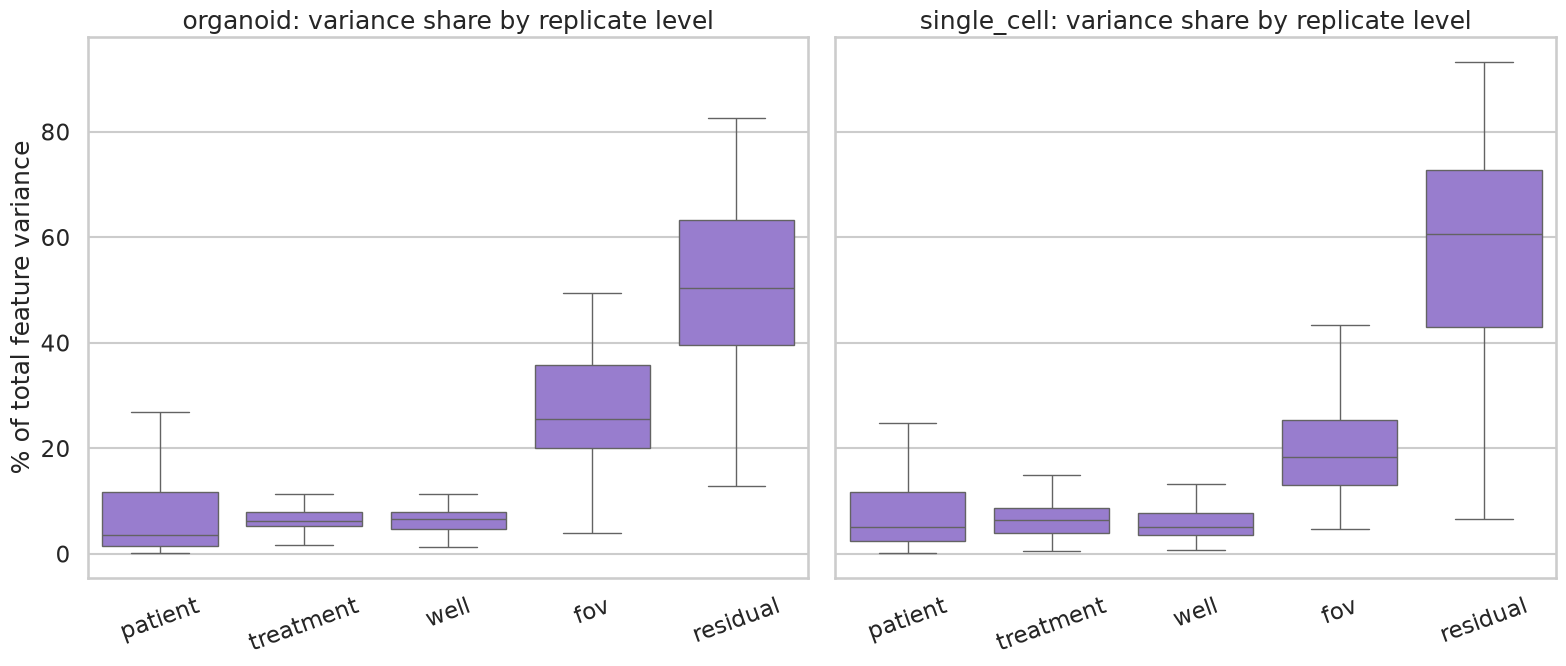

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, (name, decomposition) in zip(axes, decomposition_dfs.items()):
    plot_df = decomposition.reset_index().melt(
        id_vars="feature", var_name="level", value_name="pct_variance"
    )
    plot_df["level"] = pd.Categorical(plot_df["level"], categories=LEVEL_ORDER)
    sns.boxplot(
        data=plot_df,
        x="level",
        y="pct_variance",
        ax=ax,
        showfliers=False,
        color="mediumpurple",
    )
    ax.set_title(f"{name}: variance share by replicate level")
    ax.set_xlabel("")
    ax.set_ylabel("% of total feature variance")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(
    figures_path / "variance_by_replicate_level.png", dpi=600, bbox_inches="tight"
)
plt.show()

### Interpretation

- **`well`** capturing a non-trivial share confirms the chat finding at
  full scale: wells replicating the same (patient, treatment) combination
  differ systematically, and none of that is currently modeled — it was
  silently inflating `residual` in every notebook up to this point.
- **`fov`** isolates imaging-position effects (tiling seams, edge
  vignetting, focal-plane drift across a well) *separately* from well-level
  batch effects — a distinct, and until now unmeasured, technical noise
  source.
- Whatever remains in **`residual`** after removing patient, treatment,
  well, and FOV is the true single-object noise floor: biological
  heterogeneity between individual organoids/cells plus segmentation and
  measurement error. This is the part that *cannot* be recovered by adding
  more covariates to a group-mean model — only by aggregating (e.g.
  fitting on well-level means) or by adding object-level covariates.


## Which features are most affected by unmodeled well/FOV structure?

Rank features by how much variance `well` + `fov` account for — these are
the features whose existing `treatment`-effect estimates in
`0.linear_modeling.ipynb` are most at risk of being confounded by
plate/imaging batch effects rather than reflecting biology cleanly.


In [6]:
for name, decomposition in decomposition_dfs.items():
    ranked = decomposition.copy()
    ranked["well_plus_fov"] = ranked["well"] + ranked["fov"]
    ranked = ranked.sort_values("well_plus_fov", ascending=False)
    print(f"\n==== {name}: features most affected by well/FOV batch structure ====")
    print(ranked.head(15))


==== organoid: features most affected by well/FOV batch structure ====
                                           patient  treatment       well  \
feature                                                                    
Organoid_AGP_Intensity_MinIntensityEdge  10.472489  11.754335  15.322523   
Organoid_Mito_Granularity_16              0.810415   8.747261  11.248014   
Organoid_Mito_Granularity_15              0.702511   8.536164  12.787964   
Organoid_Mito_Granularity_14              0.624685   9.869696   9.873080   
Organoid_Mito_Granularity_13              0.611131   8.231917   7.927458   
Organoid_AGP_Granularity_13               1.827768   7.528550   8.559044   
Organoid_Mito_Granularity_12              0.806569   8.792462   9.008300   
Organoid_AGP_Granularity_16               1.138739   7.501739   8.640997   
Organoid_Mito_Granularity_11              1.169549   8.984099   9.932905   
Organoid_AGP_Granularity_15               0.967738   8.242535   9.565727   
Organoid_AGP_Gra

## Does this explain the residual dominance seen in the fitted models?

Cross-reference against `1.variate_importance.ipynb`'s saved term summary
(`results/variate_importance/{organoid,single_cell}_term_summary.parquet`):
compare its mean `residual` share against this notebook's `well + fov +
residual` combined share (i.e. everything below the treatment/patient
level). If the two are close, it confirms that most of what the pooled
model calls "unexplained" is actually structured replicate variance plus
object noise, not model failure to detect real treatment effects at a
larger scale than currently fit.


In [7]:
variate_importance_results_path = pathlib.Path(
    root_dir, "4.linear_modeling/results/variate_importance"
)

for name, decomposition in decomposition_dfs.items():
    fitted_term_summary = pd.read_parquet(
        variate_importance_results_path / f"{name}_term_summary.parquet"
    ).set_index("term")
    fitted_residual_pct = fitted_term_summary.loc["residual", "mean"]

    below_treatment_pct = decomposition[["well", "fov", "residual"]].sum(axis=1).mean()

    print(f"\n==== {name} ====")
    print(
        f"pooled-model mean residual share (0/1.variate_importance): {fitted_residual_pct:.1f}%"
    )
    print(
        f"this notebook's well + fov + object-residual share:        {below_treatment_pct:.1f}%"
    )


==== organoid ====
pooled-model mean residual share (0/1.variate_importance): 87.5%
this notebook's well + fov + object-residual share:        86.0%

==== single_cell ====
pooled-model mean residual share (0/1.variate_importance): 90.1%
this notebook's well + fov + object-residual share:        84.3%


## Summary

- The replicate hierarchy (`patient > treatment > well > FOV > object`) was
  decomposed for **every** organoid and single-cell feature via a nested
  sum-of-squares split — not a handful of spot-checked examples.
- `well` alone accounts for a share of variance that current models
  (`0.linear_modeling.ipynb` onward) fold entirely into `residual`, since
  no model in this pipeline includes a well term. That's a fixable,
  structured source of "unexplained" variance, not noise.
- `fov` isolates a second, smaller, distinct technical-noise source
  (imaging position within a well).
- Whatever's left in this notebook's own `residual` (within-FOV,
  object-to-object) is the genuine noise floor — it shrinks with
  aggregation (fewer, larger units per group) but can't be explained away
  by adding more grouping covariates.
- Practical follow-ups this motivates: refit `0.linear_modeling.ipynb`
  with `well` as an additional term (or a random effect) to recover the
  variance currently misattributed to `residual`; or refit on well-level
  aggregated means, trading object-level resolution for a much cleaner
  treatment-effect estimate (as demonstrated at the single-feature level in
  chat: R² rose from 15.5% to 52.6% when aggregating to well-level for one
  strong hit).
- Full per-feature decomposition saved to
  `4.linear_modeling/results/variance_decomposition/
  {organoid,single_cell}_nested_variance_decomposition.parquet`.
